            Price   Open   High    Low    Vol. Change %
Date                                                   
2022-01-06  60.50  61.00  61.25  60.25  27.34M   -2.02%
2022-01-07  61.25  61.25  61.75  60.50  21.96M    1.24%
2022-01-10  60.75  61.00  61.25  60.50  14.88M   -0.82%
2022-01-11  60.25  60.75  61.00  59.75  28.85M   -0.82%
2022-01-12  60.50  60.25  61.00  60.00  21.89M    0.41%


<Figure size 1000x600 with 0 Axes>

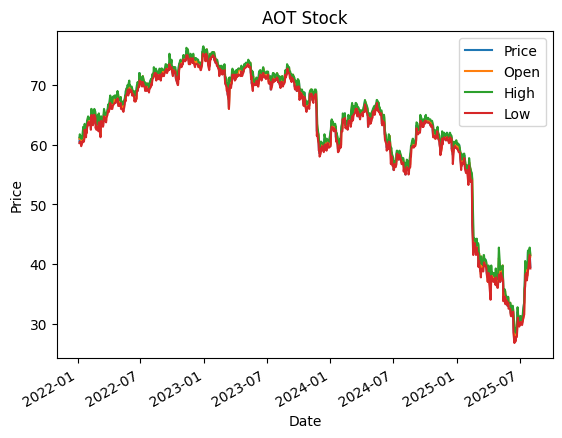

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
url = "/content/Airports of Thailand Stock Price History.csv"
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)

# ดูข้อมูลเบื้องต้น
print(df.head())
# พล็อตข้อมูล
plt.figure(figsize=(10, 6))
df.plot()
plt.title("AOT Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

            Price   Open   High    Low  Vol. Change %
Date                                                 
2025-08-01  20.38  17.40  21.90  17.39   NaN   21.89%
2025-07-31  16.72  14.99  17.17  14.74   NaN    8.01%
2025-07-30  15.48  15.87  17.27  15.44   NaN   -3.13%
2025-07-29  15.98  14.95  16.12  14.70   NaN    6.32%
2025-07-28  15.03  15.15  15.54  15.00   NaN    0.67%


<Figure size 1000x600 with 0 Axes>

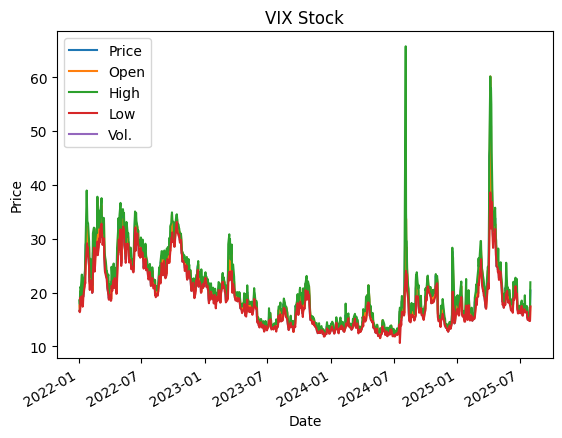

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
url = "/content/CBOE Volatility Index Historical Data.csv"
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)

# ดูข้อมูลเบื้องต้น
print(df.head())
# พล็อตข้อมูล
plt.figure(figsize=(10, 6))
df.plot()
plt.title("VIX Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

             Price
Date              
2022-01-03  334.75
2022-01-04  329.01
2022-01-05  316.38
2022-01-06  313.88
2022-01-07  314.04


<Figure size 1000x600 with 0 Axes>

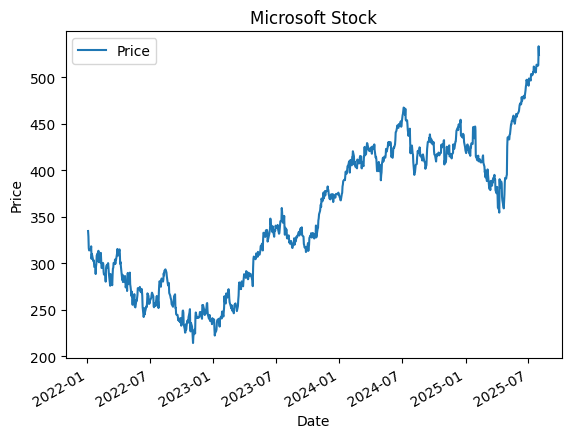

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
url = "/content/Microsoft Stock Price History.csv"
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)

# ดูข้อมูลเบื้องต้น
print(df.head())
# พล็อตข้อมูล
plt.figure(figsize=(10, 6))
df.plot()
plt.title("Microsoft Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

             Price    Open    High     Low     Vol. Change %
Date                                                        
2022-01-03  399.93  382.58  400.36  378.68  104.69M   13.53%
2022-01-04  383.20  396.52  402.67  374.35  100.25M   -4.18%
2022-01-05  362.71  382.22  390.11  360.34   80.12M   -5.35%
2022-01-06  354.90  359.00  362.67  340.17   90.34M   -2.15%
2022-01-07  342.32  360.12  360.31  336.67   84.16M   -3.54%


<Figure size 1000x600 with 0 Axes>

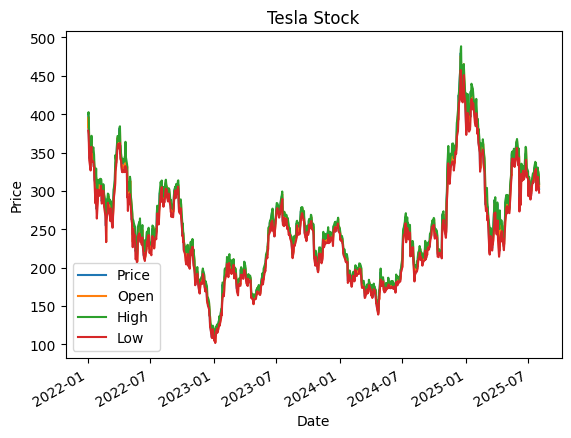

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
url = "/content/Tesla.csv"
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)

# ดูข้อมูลเบื้องต้น
print(df.head())
# พล็อตข้อมูล
plt.figure(figsize=(10, 6))
df.plot()
plt.title("Tesla Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Training model... This might take a moment.
Model training completed in 162.54 seconds.
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

--- Model Performance Metrics ---
Train Score: 1.08 RMSE
Test Score: 6.64 RMSE
Train Score: 0.80 MAE
Test Score: 5.10 MAE
Train Score: 1.19 MAPE %
Test Score: 14.36 MAPE %

Test predictions exported to lstm_result.csv


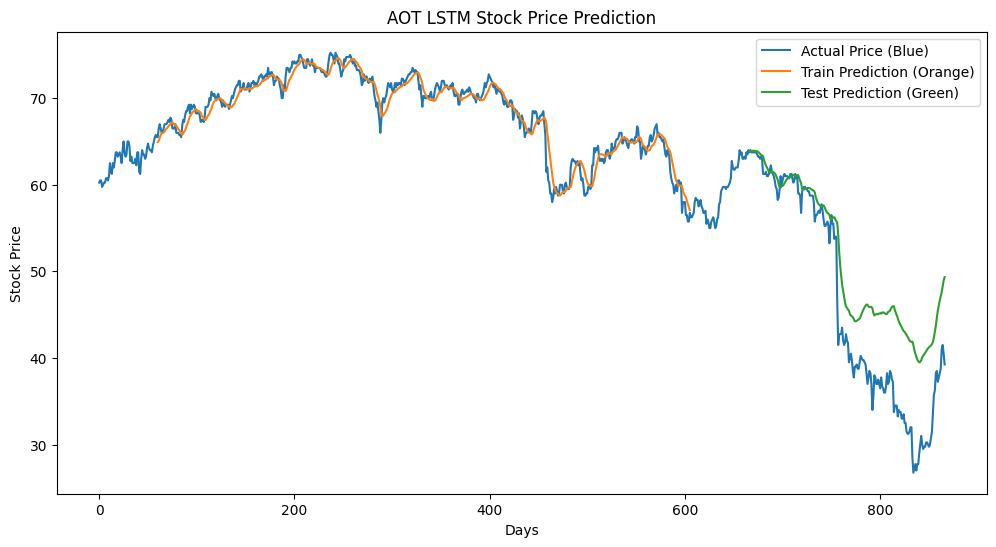


--- 30-Day Future Prediction ---
Predicted prices(AOT) for the next 30 days:
[[49.46]
 [50.94]
 [52.5 ]
 [54.14]
 [55.84]
 [57.57]
 [59.33]
 [61.08]
 [62.81]
 [64.5 ]
 [66.13]
 [67.68]
 [69.15]
 [70.51]
 [71.77]
 [72.91]
 [73.95]
 [74.87]
 [75.7 ]
 [76.43]
 [77.08]
 [77.66]
 [78.17]
 [78.63]
 [79.04]
 [79.41]
 [79.75]
 [80.06]
 [80.34]
 [80.61]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input # Import Input layer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import time #helper libraries

# --- Configuration ---
input_file="/content/Airports of Thailand Stock Price History.csv"
look_back = 60 # Reduced Timestep for LSTM to ensure test data availability
np.random.seed(42) # fix random seed for reproducibility

# --- Function to Prepare Dataset for LSTM ---
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    # Ensure there are enough data points to create at least one sequence
    if len(dataset) > look_back:
        # The loop runs up to the point where the last sequence ends one step before the end of the dataset
        for i in range(len(dataset) - look_back):
            # X is the sequence of 'look_back' previous values
            a = dataset[i:(i + look_back), 0]
            # Y is the value immediately following the sequence Y
            dataX.append(a)
            dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# --- Data Loading and Preprocessing ---

# load the dataset
try:
    df = read_csv(input_file)
except FileNotFoundError:
    print(f"Error: File not found at {input_file}. Please ensure the file is uploaded.")
    exit()

# take close price column (index 4 for 'Price' in your file structure)
# Assuming 'Price' is the 5th column (index 4)
all_y = df[df.columns[4]].values
dataset=all_y.reshape(-1, 1)

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# split into train and test sets, 70% training data, 30% test data
train_size = int(len(dataset) * 0.7)
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# reshape into X=t and Y=t+1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))

# Check if testX is empty before reshaping
if testX.shape[0] > 0:
    testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
    test_data_available = True
else:
    # If the test set is too small (less than look_back), testX will be empty
    print("Test dataset is too small to create sequences with the given look_back.")
    test_data_available = False

# --- Model Building and Training ---

# create and fit the LSTM network, optimizer=adam, 25 neurons, dropout 0.1
model = Sequential()
# Use Input layer to specify input shape
model.add(Input(shape=(look_back, 1)))
model.add(LSTM(25)) # Input shape is inferred from the Input layer
model.add(Dropout(0.1))
model.add(Dense(1)) # Output layer for a single prediction
model.compile(loss='mse', optimizer='adam')

print("Training model... This might take a moment.")
start_time = time.time()
model.fit(trainX, trainY, epochs=1000, batch_size=240, verbose=0)
end_time = time.time()
print(f"Model training completed in {end_time - start_time:.2f} seconds.")

# --- Evaluation and Metrics ---

# make predictions
trainPredict = model.predict(trainX)
if test_data_available:
    testPredict = model.predict(testX)
else:
    testPredict = np.array([])


# invert predictions and actual values to original scale
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1)) # Reshape for inverse_transform
if test_data_available:
    testPredict = scaler.inverse_transform(testPredict)
    testY = scaler.inverse_transform(testY.reshape(-1, 1))
else:
    testY = np.array([[]])


# calculate error metrics (RMSE, MAE, MAPE)
print("\n--- Model Performance Metrics ---")

# RMSE
trainScore_rmse = math.sqrt(mean_squared_error(trainY[:,0], trainPredict[:,0]))
print(f'Train Score: {trainScore_rmse:.2f} RMSE')
if test_data_available:
    testScore_rmse = math.sqrt(mean_squared_error(testY[:,0], testPredict[:,0]))
    print(f'Test Score: {testScore_rmse:.2f} RMSE')
else:
    print('Test Score: N/A RMSE (Test dataset too small)')

# MAE
trainMAE = mean_absolute_error(trainY[:,0], trainPredict[:,0])
print(f'Train Score: {trainMAE:.2f} MAE')
if test_data_available:
    testMAE = mean_absolute_error(testY[:,0], testPredict[:,0])
    print(f'Test Score: {testMAE:.2f} MAE')
else:
    print('Test Score: N/A MAE (Test dataset too small)')

# MAPE
# Note: Added a small constant (epsilon) to avoid division by zero for robustness, though unlikely with stock prices.
epsilon = 1e-10
trainMAPE = mean_absolute_percentage_error(trainY[:,0] + epsilon, trainPredict[:,0]) * 100
print(f'Train Score: {trainMAPE:.2f} MAPE %')
if test_data_available:
    testMAPE = mean_absolute_percentage_error(testY[:,0] + epsilon, testPredict[:,0]) * 100
    print(f'Test Score: {testMAPE:.2f} MAPE %')
else:
    print('Test Score: N/A MAPE % (Test dataset too small)')

# --- Plotting and Exporting ---

# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
# The training prediction starts after the first 'look_back' days
trainPredictPlot[look_back:len(trainPredict) + look_back, :] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
if test_data_available:
    # The test prediction starts after the last point of the training set used for training
    # which is len(train) - look_back, plus the look_back days.
    # The index to start plotting the test predictions is at len(train) + look_back
    test_start_index = len(train) + look_back
    testPredictPlot[test_start_index:test_start_index + len(testPredict), :] = testPredict

    # Get the actual test prices for comparison
    testPrices = scaler.inverse_transform(test[look_back:look_back + len(testPredict),:])

    # Export prediction and actual prices
    df_result = pd.DataFrame(data={
        "prediction": np.around(testPredict.flatten(), decimals=2),
        "test_price": np.around(testPrices.flatten(), decimals=2)
    })
    df_result.to_csv("lstm_result.csv", sep=';', index=None)
    print("\nTest predictions exported to lstm_result.csv")


# plot baseline (actual prices), train predictions, and test predictions
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(dataset), label='Actual Price (Blue)') # Actual/Baseline
plt.plot(trainPredictPlot, label='Train Prediction (Orange)') # Train prediction
if test_data_available:
    plt.plot(testPredictPlot, label='Test Prediction (Green)') # Test prediction
    plt.title('AOT LSTM Stock Price Prediction')
    plt.xlabel('Days')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()
else:
    plt.title('LSTM Stock Price Prediction (No Test Data for Plot)')
    plt.xlabel('Days')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()
    print("Not enough data to plot test predictions.")

# --- Future Prediction (Next 30 Days) ---

print("\n--- 30-Day Future Prediction ---")
# Get the last 'look_back' days from the *entire* dataset for the initial prediction sequence
last_look_back_days = dataset[-look_back:]
last_look_back_days = last_look_back_days.reshape(1, look_back, 1)

predicted_prices = []
current_batch = last_look_back_days

# Loop 30 times for 30 days of prediction
for i in range(30):
    # Predict the next value
    predicted_price_scaled = model.predict(current_batch, verbose=0)
    # Store the predicted value
    predicted_prices.append(predicted_price_scaled[0,0])

    # Update the input sequence: drop the oldest value and add the new prediction
    # current_batch[:,1:,:] is the sequence excluding the first element
    # Reshape the predicted price to match the dimensions of current_batch[:,1:,:]
    predicted_price_reshaped = predicted_price_scaled.reshape(1, 1, 1)
    current_batch = np.append(current_batch[:,1:,:], predicted_price_reshaped, axis=1)


# Inverse transform the 30 predicted values back to the original price scale
predicted_prices = scaler.inverse_transform(np.array(predicted_prices).reshape(-1, 1))

print("Predicted prices(AOT) for the next 30 days:")
print(np.around(predicted_prices, decimals=2))

In [ ]:
# เรียกใช้โค้ดเดิมอีกครั้งเพื่อให้แสดงผลภาษาไทยได้ถูกต้อง
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input # Import Input layer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import time #helper libraries

# --- Configuration ---
input_file="/content/Airports of Thailand Stock Price History.csv"
look_back = 60 # Reduced Timestep for LSTM to ensure test data availability
np.random.seed(42) # fix random seed for reproducibility

# --- Function to Prepare Dataset for LSTM ---
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    # Ensure there are enough data points to create at least one sequence
    if len(dataset) > look_back:
        # The loop runs up to the point where the last sequence ends one step before the end of the dataset
        for i in range(len(dataset) - look_back):
            # X is the sequence of 'look_back' previous values
            a = dataset[i:(i + look_back), 0]
            # Y is the value immediately following the sequence Y
            dataX.append(a)
            dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# --- Data Loading and Preprocessing ---

# load the dataset
try:
    df = read_csv(input_file)
except FileNotFoundError:
    print(f"Error: File not found at {input_file}. Please ensure the file is uploaded.")
    exit()

# take close price column (index 4 for 'Price' in your file structure)
# Assuming 'Price' is the 5th column (index 4)
all_y = df[df.columns[4]].values
dataset=all_y.reshape(-1, 1)

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# split into train and test sets, 70% training data, 30% test data
train_size = int(len(dataset) * 0.7)
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# reshape into X=t and Y=t+1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))

# Check if testX is empty before reshaping
if testX.shape[0] > 0:
    testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
    test_data_available = True
else:
    # If the test set is too small (less than look_back), testX will be empty
    print("Test dataset is too small to create sequences with the given look_back.")
    test_data_available = False

# --- Model Building and Training ---

# create and fit the LSTM network, optimizer=adam, 25 neurons, dropout 0.1
model = Sequential()
# Use Input layer to specify input shape
model.add(Input(shape=(look_back, 1)))
model.add(LSTM(25)) # Input shape is inferred from the Input layer
model.add(Dropout(0.1))
model.add(Dense(1)) # Output layer for a single prediction
model.compile(loss='mse', optimizer='adam')

print("Training model... This might take a moment.")
start_time = time.time()
model.fit(trainX, trainY, epochs=1000, batch_size=240, verbose=0)
end_time = time.time()
print(f"Model training completed in {end_time - start_time:.2f} seconds.")

# --- Evaluation and Metrics ---

# make predictions
trainPredict = model.predict(trainX)
if test_data_available:
    testPredict = model.predict(testX)
else:
    testPredict = np.array([])


# invert predictions and actual values to original scale
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1)) # Reshape for inverse_transform
if test_data_available:
    testPredict = scaler.inverse_transform(testPredict)
    testY = scaler.inverse_transform(testY.reshape(-1, 1))
else:
    testY = np.array([[]])


# calculate error metrics (RMSE, MAE, MAPE)
print("\n--- Model Performance Metrics ---")

# RMSE
trainScore_rmse = math.sqrt(mean_squared_error(trainY[:,0], trainPredict[:,0]))
print(f'Train Score: {trainScore_rmse:.2f} RMSE')
if test_data_available:
    testScore_rmse = math.sqrt(mean_squared_error(testY[:,0], testPredict[:,0]))
    print(f'Test Score: {testScore_rmse:.2f} RMSE')
else:
    print('Test Score: N/A RMSE (Test dataset too small)')

# MAE
trainMAE = mean_absolute_error(trainY[:,0], trainPredict[:,0])
print(f'Train Score: {trainMAE:.2f} MAE')
if test_data_available:
    testMAE = mean_absolute_error(testY[:,0], testPredict[:,0])
    print(f'Test Score: {testMAE:.2f} MAE')
else:
    print('Test Score: N/A MAE (Test dataset too small)')

# MAPE
# Note: Added a small constant (epsilon) to avoid division by zero for robustness, though unlikely with stock prices.
epsilon = 1e-10
trainMAPE = mean_absolute_percentage_error(trainY[:,0] + epsilon, trainPredict[:,0]) * 100
print(f'Train Score: {trainMAPE:.2f} MAPE %')
if test_data_available:
    testMAPE = mean_absolute_percentage_error(testY[:,0] + epsilon, testPredict[:,0]) * 100
    print(f'Test Score: {testMAPE:.2f} MAPE %')
else:
    print('Test Score: N/A MAPE % (Test dataset too small)')

# --- Plotting and Exporting ---

# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
# The training prediction starts after the first 'look_back' days
trainPredictPlot[look_back:len(trainPredict) + look_back, :] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
if test_data_available:
    # The test prediction starts after the last point of the training set used for training
    # which is len(train) - look_back, plus the look_back days.
    # The index to start plotting the test predictions is at len(train) + look_back
    test_start_index = len(train) + look_back
    testPredictPlot[test_start_index:test_start_index + len(testPredict), :] = testPredict

    # Get the actual test prices for comparison
    testPrices = scaler.inverse_transform(test[look_back:look_back + len(testPredict),:])

    # Export prediction and actual prices
    df_result = pd.DataFrame(data={
        "prediction": np.around(testPredict.flatten(), decimals=2),
        "test_price": np.around(testPrices.flatten(), decimals=2)
    })
    df_result.to_csv("lstm_result.csv", sep=';', index=None)
    print("\nTest predictions exported to lstm_result.csv")


# plot baseline (actual prices), train predictions, and test predictions
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(dataset), label='ราคาจริง (สีน้ำเงิน)') # Actual/Baseline
plt.plot(trainPredictPlot, label='การทำนาย Train (สีส้ม)') # Train prediction
if test_data_available:
    plt.plot(testPredictPlot, label='การทำนาย Test (สีเขียว)') # Test prediction
    plt.title('การทำนายราคาหุ้น AOT ด้วย LSTM')
    plt.xlabel('วัน')
    plt.ylabel('ราคาหุ้น')
    plt.legend()
    plt.show()
else:
    plt.title('การทำนายราคาหุ้นด้วย LSTM (ไม่มีข้อมูล Test สำหรับพล็อต)')
    plt.xlabel('วัน')
    plt.ylabel('ราคาหุ้น')
    plt.legend()
    plt.show()
    print("มีข้อมูลไม่เพียงพอสำหรับพล็อตการทำนาย test")

# --- Future Prediction (Next 30 Days) ---

print("\n--- 30-Day Future Prediction ---")
# Get the last 'look_back' days from the *entire* dataset for the initial prediction sequence
last_look_back_days = dataset[-look_back:]
last_look_back_days = last_look_back_days.reshape(1, look_back, 1)

predicted_prices = []
current_batch = last_look_back_days

# Loop 30 times for 30 days of prediction
for i in range(30):
    # Predict the next value
    predicted_price_scaled = model.predict(current_batch, verbose=0)
    # Store the predicted value
    predicted_prices.append(predicted_price_scaled[0,0])

    # Update the input sequence: drop the oldest value and add the new prediction
    # current_batch[:,1:,:] is the sequence excluding the first element
    # Reshape the predicted price to match the dimensions of current_batch[:,1:,:]
    predicted_price_reshaped = predicted_price_scaled.reshape(1, 1, 1)
    current_batch = np.append(current_batch[:,1:,:], predicted_price_reshaped, axis=1)


# Inverse transform the 30 predicted values back to the original price scale
predicted_prices = scaler.inverse_transform(np.array(predicted_prices).reshape(-1, 1))

print("ราคาที่ทำนาย (AOT) สำหรับ 30 วันถัดไป:")
print(np.around(predicted_prices, decimals=2))

Training model... This might take a moment.
Model training completed in 164.64 seconds.
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

--- Model Performance Metrics ---
Train Score: 0.97 RMSE
Test Score: 1.53 RMSE
Train Score: 0.70 MAE
Test Score: 0.97 MAE
Train Score: 3.68 MAPE %
Test Score: 4.95 MAPE %

Test predictions exported to lstm_result.csv


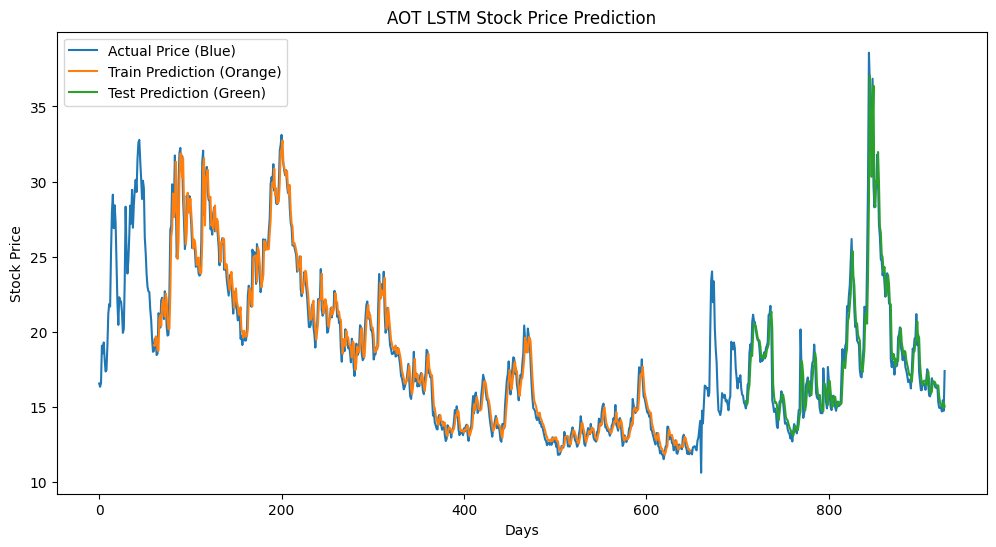


--- 30-Day Future Prediction ---
Predicted prices(AOT) for the next 30 days:
[[16.59]
 [16.59]
 [16.56]
 [16.53]
 [16.49]
 [16.47]
 [16.45]
 [16.43]
 [16.43]
 [16.42]
 [16.42]
 [16.42]
 [16.43]
 [16.42]
 [16.42]
 [16.42]
 [16.41]
 [16.41]
 [16.4 ]
 [16.39]
 [16.38]
 [16.37]
 [16.36]
 [16.35]
 [16.35]
 [16.34]
 [16.33]
 [16.32]
 [16.31]
 [16.3 ]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input # Import Input layer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import time #helper libraries

# --- Configuration ---
input_file="/content/CBOE Volatility Index Historical Data.csv"
look_back = 60 # Reduced Timestep for LSTM to ensure test data availability
np.random.seed(42) # fix random seed for reproducibility

# --- Function to Prepare Dataset for LSTM ---
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    # Ensure there are enough data points to create at least one sequence
    if len(dataset) > look_back:
        # The loop runs up to the point where the last sequence ends one step before the end of the dataset
        for i in range(len(dataset) - look_back):
            # X is the sequence of 'look_back' previous values
            a = dataset[i:(i + look_back), 0]
            # Y is the value immediately following the sequence Y
            dataX.append(a)
            dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# --- Data Loading and Preprocessing ---

# load the dataset
try:
    df = read_csv(input_file)
except FileNotFoundError:
    print(f"Error: File not found at {input_file}. Please ensure the file is uploaded.")
    exit()

# take close price column (index 4 for 'Price' in your file structure)
# Assuming 'Price' is the 5th column (index 4)
all_y = df[df.columns[4]].values
dataset=all_y.reshape(-1, 1)

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# split into train and test sets, 70% training data, 30% test data
train_size = int(len(dataset) * 0.7)
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# reshape into X=t and Y=t+1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))

# Check if testX is empty before reshaping
if testX.shape[0] > 0:
    testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
    test_data_available = True
else:
    # If the test set is too small (less than look_back), testX will be empty
    print("Test dataset is too small to create sequences with the given look_back.")
    test_data_available = False

# --- Model Building and Training ---

# create and fit the LSTM network, optimizer=adam, 25 neurons, dropout 0.1
model = Sequential()
# Use Input layer to specify input shape
model.add(Input(shape=(look_back, 1)))
model.add(LSTM(25)) # Input shape is inferred from the Input layer
model.add(Dropout(0.1))
model.add(Dense(1)) # Output layer for a single prediction
model.compile(loss='mse', optimizer='adam')

print("Training model... This might take a moment.")
start_time = time.time()
model.fit(trainX, trainY, epochs=1000, batch_size=240, verbose=0)
end_time = time.time()
print(f"Model training completed in {end_time - start_time:.2f} seconds.")

# --- Evaluation and Metrics ---

# make predictions
trainPredict = model.predict(trainX)
if test_data_available:
    testPredict = model.predict(testX)
else:
    testPredict = np.array([])


# invert predictions and actual values to original scale
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1)) # Reshape for inverse_transform
if test_data_available:
    testPredict = scaler.inverse_transform(testPredict)
    testY = scaler.inverse_transform(testY.reshape(-1, 1))
else:
    testY = np.array([[]])


# calculate error metrics (RMSE, MAE, MAPE)
print("\n--- Model Performance Metrics ---")

# RMSE
trainScore_rmse = math.sqrt(mean_squared_error(trainY[:,0], trainPredict[:,0]))
print(f'Train Score: {trainScore_rmse:.2f} RMSE')
if test_data_available:
    testScore_rmse = math.sqrt(mean_squared_error(testY[:,0], testPredict[:,0]))
    print(f'Test Score: {testScore_rmse:.2f} RMSE')
else:
    print('Test Score: N/A RMSE (Test dataset too small)')

# MAE
trainMAE = mean_absolute_error(trainY[:,0], trainPredict[:,0])
print(f'Train Score: {trainMAE:.2f} MAE')
if test_data_available:
    testMAE = mean_absolute_error(testY[:,0], testPredict[:,0])
    print(f'Test Score: {testMAE:.2f} MAE')
else:
    print('Test Score: N/A MAE (Test dataset too small)')

# MAPE
# Note: Added a small constant (epsilon) to avoid division by zero for robustness, though unlikely with stock prices.
epsilon = 1e-10
trainMAPE = mean_absolute_percentage_error(trainY[:,0] + epsilon, trainPredict[:,0]) * 100
print(f'Train Score: {trainMAPE:.2f} MAPE %')
if test_data_available:
    testMAPE = mean_absolute_percentage_error(testY[:,0] + epsilon, testPredict[:,0]) * 100
    print(f'Test Score: {testMAPE:.2f} MAPE %')
else:
    print('Test Score: N/A MAPE % (Test dataset too small)')

# --- Plotting and Exporting ---

# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
# The training prediction starts after the first 'look_back' days
trainPredictPlot[look_back:len(trainPredict) + look_back, :] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
if test_data_available:
    # The test prediction starts after the last point of the training set used for training
    # which is len(train) - look_back, plus the look_back days.
    # The index to start plotting the test predictions is at len(train) + look_back
    test_start_index = len(train) + look_back
    testPredictPlot[test_start_index:test_start_index + len(testPredict), :] = testPredict

    # Get the actual test prices for comparison
    testPrices = scaler.inverse_transform(test[look_back:look_back + len(testPredict),:])

    # Export prediction and actual prices
    df_result = pd.DataFrame(data={
        "prediction": np.around(testPredict.flatten(), decimals=2),
        "test_price": np.around(testPrices.flatten(), decimals=2)
    })
    df_result.to_csv("lstm_result.csv", sep=';', index=None)
    print("\nTest predictions exported to lstm_result.csv")


# plot baseline (actual prices), train predictions, and test predictions
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(dataset), label='Actual Price (Blue)') # Actual/Baseline
plt.plot(trainPredictPlot, label='Train Prediction (Orange)') # Train prediction
if test_data_available:
    plt.plot(testPredictPlot, label='Test Prediction (Green)') # Test prediction
    plt.title('AOT LSTM Stock Price Prediction')
    plt.xlabel('Days')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()
else:
    plt.title('LSTM Stock Price Prediction (No Test Data for Plot)')
    plt.xlabel('Days')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()
    print("Not enough data to plot test predictions.")

# --- Future Prediction (Next 30 Days) ---

print("\n--- 30-Day Future Prediction ---")
# Get the last 'look_back' days from the *entire* dataset for the initial prediction sequence
last_look_back_days = dataset[-look_back:]
last_look_back_days = last_look_back_days.reshape(1, look_back, 1)

predicted_prices = []
current_batch = last_look_back_days

# Loop 30 times for 30 days of prediction
for i in range(30):
    # Predict the next value
    predicted_price_scaled = model.predict(current_batch, verbose=0)
    # Store the predicted value
    predicted_prices.append(predicted_price_scaled[0,0])

    # Update the input sequence: drop the oldest value and add the new prediction
    # current_batch[:,1:,:] is the sequence excluding the first element
    # Reshape the predicted price to match the dimensions of current_batch[:,1:,:]
    predicted_price_reshaped = predicted_price_scaled.reshape(1, 1, 1)
    current_batch = np.append(current_batch[:,1:,:], predicted_price_reshaped, axis=1)


# Inverse transform the 30 predicted values back to the original price scale
predicted_prices = scaler.inverse_transform(np.array(predicted_prices).reshape(-1, 1))

print("Predicted prices(AOT) for the next 30 days:")
print(np.around(predicted_prices, decimals=2))

Training model... This might take a moment.
Model training completed in 162.08 seconds.
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

--- Model Performance Metrics ---
Train Score: 6.34 RMSE
Test Score: 8.30 RMSE
Train Score: 4.93 MAE
Test Score: 5.84 MAE
Train Score: 1.66 MAPE %
Test Score: 1.40 MAPE %

Test predictions exported to lstm_result.csv


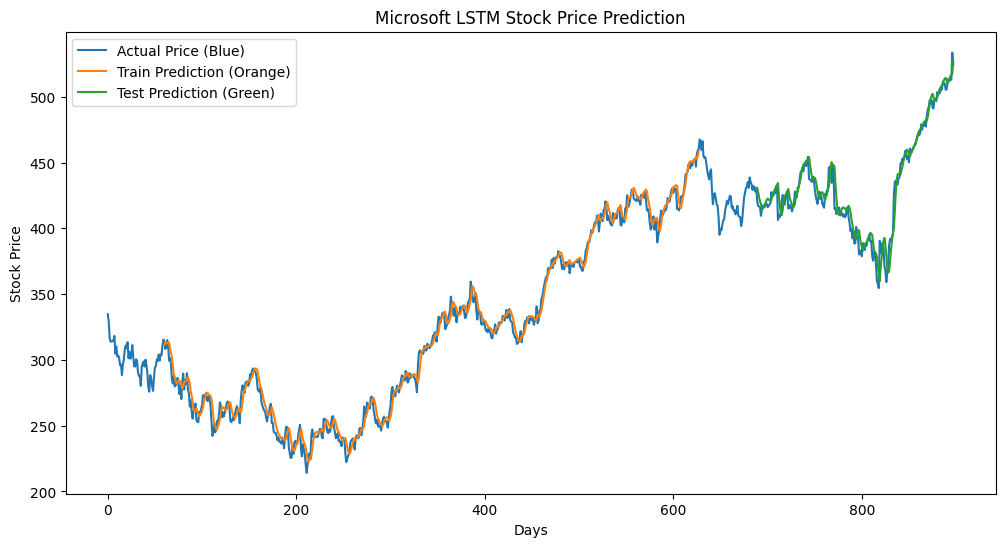


--- 30-Day Future Prediction ---
Predicted prices for the next 30 days:
[[530.4 ]
 [534.36]
 [538.02]
 [541.37]
 [544.44]
 [547.24]
 [549.83]
 [552.25]
 [554.55]
 [556.77]
 [558.94]
 [561.11]
 [563.29]
 [565.5 ]
 [567.74]
 [570.03]
 [572.36]
 [574.74]
 [577.15]
 [579.59]
 [582.05]
 [584.53]
 [587.02]
 [589.51]
 [592.01]
 [594.49]
 [596.97]
 [599.43]
 [601.88]
 [604.31]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input # Import Input layer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import time #helper libraries

# --- Configuration ---
input_file="/content/Microsoft Stock Price History.csv"
look_back = 60 # Reduced Timestep for LSTM to ensure test data availability
np.random.seed(42) # fix random seed for reproducibility

# --- Function to Prepare Dataset for LSTM ---
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    # Ensure there are enough data points to create at least one sequence
    if len(dataset) > look_back:
        # The loop runs up to the point where the last sequence ends one step before the end of the dataset
        for i in range(len(dataset) - look_back):
            # X is the sequence of 'look_back' previous values
            a = dataset[i:(i + look_back), 0]
            # Y is the value immediately following the sequence Y
            dataX.append(a)
            dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# --- Data Loading and Preprocessing ---

# load the dataset
try:
    df = read_csv(input_file, parse_dates=['Date']) # Parse 'Date' column as dates
    df.set_index('Date', inplace=True) # Set 'Date' column as index

except FileNotFoundError:
    print(f"Error: File not found at {input_file}. Please ensure the file is uploaded.")
    exit()

# take close price column (index 0 for 'Price' in this file structure)
# Assuming 'Price' is the 1st column (index 0)
all_y = df['Price'].values
dataset=all_y.reshape(-1, 1)

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# split into train and test sets, 70% training data, 30% test data
train_size = int(len(dataset) * 0.7)
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# reshape into X=t and Y=t+1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))

# Check if testX is empty before reshaping
if testX.shape[0] > 0:
    testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
    test_data_available = True
else:
    # If the test set is too small (less than look_back), testX will be empty
    print("Test dataset is too small to create sequences with the given look_back.")
    test_data_available = False

# --- Model Building and Training ---

# create and fit the LSTM network, optimizer=adam, 25 neurons, dropout 0.1
model = Sequential()
# Use Input layer to specify input shape
model.add(Input(shape=(look_back, 1)))
model.add(LSTM(25)) # Input shape is inferred from the Input layer
model.add(Dropout(0.1))
model.add(Dense(1)) # Output layer for a single prediction
model.compile(loss='mse', optimizer='adam')

print("Training model... This might take a moment.")
start_time = time.time()
model.fit(trainX, trainY, epochs=1000, batch_size=240, verbose=0)
end_time = time.time()
print(f"Model training completed in {end_time - start_time:.2f} seconds.")

# --- Evaluation and Metrics ---

# make predictions
trainPredict = model.predict(trainX)
if test_data_available:
    testPredict = model.predict(testX)
else:
    testPredict = np.array([])


# invert predictions and actual values to original scale
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1)) # Reshape for inverse_transform
if test_data_available:
    testPredict = scaler.inverse_transform(testPredict)
    testY = scaler.inverse_transform(testY.reshape(-1, 1))
else:
    testY = np.array([[]])


# calculate error metrics (RMSE, MAE, MAPE)
print("\n--- Model Performance Metrics ---")

# RMSE
trainScore_rmse = math.sqrt(mean_squared_error(trainY[:,0], trainPredict[:,0]))
print(f'Train Score: {trainScore_rmse:.2f} RMSE')
if test_data_available:
    testScore_rmse = math.sqrt(mean_squared_error(testY[:,0], testPredict[:,0]))
    print(f'Test Score: {testScore_rmse:.2f} RMSE')
else:
    print('Test Score: N/A RMSE (Test dataset too small)')

# MAE
trainMAE = mean_absolute_error(trainY[:,0], trainPredict[:,0])
print(f'Train Score: {trainMAE:.2f} MAE')
if test_data_available:
    testMAE = mean_absolute_error(testY[:,0], testPredict[:,0])
    print(f'Test Score: {testMAE:.2f} MAE')
else:
    print('Test Score: N/A MAE (Test dataset too small)')

# MAPE
# Note: Added a small constant (epsilon) to avoid division by zero for robustness, though unlikely with stock prices.
epsilon = 1e-10
trainMAPE = mean_absolute_percentage_error(trainY[:,0] + epsilon, trainPredict[:,0]) * 100
print(f'Train Score: {trainMAPE:.2f} MAPE %')
if test_data_available:
    testMAPE = mean_absolute_percentage_error(testY[:,0] + epsilon, testPredict[:,0]) * 100
    print(f'Test Score: {testMAPE:.2f} MAPE %')
else:
    print('Test Score: N/A MAPE % (Test dataset too small)')

# --- Plotting and Exporting ---

# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
# The training prediction starts after the first 'look_back' days
trainPredictPlot[look_back:len(trainPredict) + look_back, :] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
if test_data_available:
    # The test prediction starts after the last point of the training set used for training
    # which is len(train) - look_back, plus the look_back days.
    # The index to start plotting the test predictions is at len(train) + look_back
    test_start_index = len(train) + look_back
    testPredictPlot[test_start_index:test_start_index + len(testPredict), :] = testPredict

    # Get the actual test prices for comparison
    testPrices = scaler.inverse_transform(test[look_back:look_back + len(testPredict),:])

    # Export prediction and actual prices
    df_result = pd.DataFrame(data={
        "prediction": np.around(testPredict.flatten(), decimals=2),
        "test_price": np.around(testPrices.flatten(), decimals=2)
    })
    df_result.to_csv("lstm_result.csv", sep=';', index=None)
    print("\nTest predictions exported to lstm_result.csv")


# plot baseline (actual prices), train predictions, and test predictions
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(dataset), label='Actual Price (Blue)') # Actual/Baseline
plt.plot(trainPredictPlot, label='Train Prediction (Orange)') # Train prediction
if test_data_available:
    plt.plot(testPredictPlot, label='Test Prediction (Green)') # Test prediction
    plt.title('Microsoft LSTM Stock Price Prediction')
    plt.xlabel('Days')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()
else:
    plt.title('LSTM Stock Price Prediction (No Test Data for Plot)')
    plt.xlabel('Days')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()
    print("Not enough data to plot test predictions.")

# --- Future Prediction (Next 30 Days) ---

print("\n--- 30-Day Future Prediction ---")
# Get the last 'look_back' days from the *entire* dataset for the initial prediction sequence
last_look_back_days = dataset[-look_back:]
last_look_back_days = last_look_back_days.reshape(1, look_back, 1)

predicted_prices = []
current_batch = last_look_back_days

# Loop 30 times for 30 days of prediction
for i in range(30):
    # Predict the next value
    predicted_price_scaled = model.predict(current_batch, verbose=0)
    # Store the predicted value
    predicted_prices.append(predicted_price_scaled[0,0])

    # Update the input sequence: drop the oldest value and add the new prediction
    # current_batch[:,1:,:] is the sequence excluding the first element
    # Reshape the predicted price to match the dimensions of current_batch[:,1:,:]
    predicted_price_reshaped = predicted_price_scaled.reshape(1, 1, 1)
    current_batch = np.append(current_batch[:,1:,:], predicted_price_reshaped, axis=1)


# Inverse transform the 30 predicted values back to the original price scale
predicted_prices = scaler.inverse_transform(np.array(predicted_prices).reshape(-1, 1))

print("Predicted prices for the next 30 days:")
print(np.around(predicted_prices, decimals=2))

Training model... This might take a moment.
Model training completed in 163.07 seconds.
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- Model Performance Metrics ---
Train Score: 7.46 RMSE
Test Score: 13.66 RMSE
Train Score: 5.67 MAE
Test Score: 10.60 MAE
Train Score: 2.68 MAPE %
Test Score: 3.44 MAPE %

Test predictions exported to lstm_result.csv


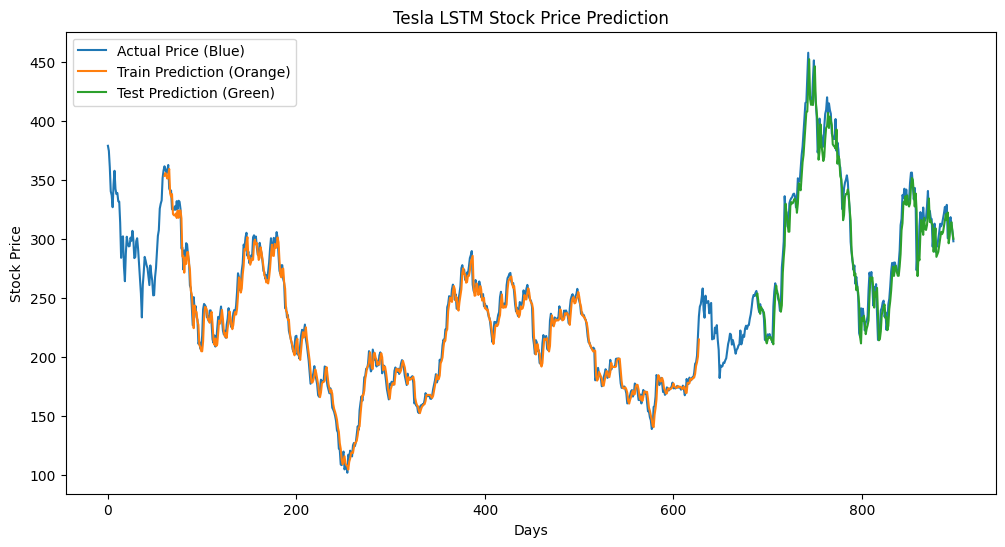


--- 30-Day Future Prediction ---
Predicted prices for the next 30 days:
[[292.72]
 [287.91]
 [283.44]
 [278.89]
 [274.21]
 [269.44]
 [264.66]
 [259.94]
 [255.31]
 [250.82]
 [246.47]
 [242.29]
 [238.29]
 [234.47]
 [230.84]
 [227.39]
 [224.12]
 [221.04]
 [218.13]
 [215.39]
 [212.81]
 [210.4 ]
 [208.13]
 [206.01]
 [204.02]
 [202.16]
 [200.43]
 [198.81]
 [197.3 ]
 [195.9 ]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input # Import Input layer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import time #helper libraries

# --- Configuration ---
input_file="/content/Tesla.csv"
look_back = 60 # Reduced Timestep for LSTM to ensure test data availability
np.random.seed(42) # fix random seed for reproducibility

# --- Function to Prepare Dataset for LSTM ---
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    # Ensure there are enough data points to create at least one sequence
    if len(dataset) > look_back:
        # The loop runs up to the point where the last sequence ends one step before the end of the dataset
        for i in range(len(dataset) - look_back):
            # X is the sequence of 'look_back' previous values
            a = dataset[i:(i + look_back), 0]
            # Y is the value immediately following the sequence Y
            dataX.append(a)
            dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# --- Data Loading and Preprocessing ---

# load the dataset
try:
    df = read_csv(input_file)
except FileNotFoundError:
    print(f"Error: File not found at {input_file}. Please ensure the file is uploaded.")
    exit()

# take close price column (index 4 for 'Price' in this file structure)
# Assuming 'Price' is the 5th column (index 4)
all_y = df[df.columns[4]].values
dataset=all_y.reshape(-1, 1)

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# split into train and test sets, 70% training data, 30% test data
train_size = int(len(dataset) * 0.7)
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# reshape into X=t and Y=t+1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))

# Check if testX is empty before reshaping
if testX.shape[0] > 0:
    testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
    test_data_available = True
else:
    # If the test set is too small (less than look_back), testX will be empty
    print("Test dataset is too small to create sequences with the given look_back.")
    test_data_available = False

# --- Model Building and Training ---

# create and fit the LSTM network, optimizer=adam, 25 neurons, dropout 0.1
model = Sequential()
# Use Input layer to specify input shape
model.add(Input(shape=(look_back, 1)))
model.add(LSTM(25)) # Input shape is inferred from the Input layer
model.add(Dropout(0.1))
model.add(Dense(1)) # Output layer for a single prediction
model.compile(loss='mse', optimizer='adam')

print("Training model... This might take a moment.")
start_time = time.time()
model.fit(trainX, trainY, epochs=1000, batch_size=240, verbose=0)
end_time = time.time()
print(f"Model training completed in {end_time - start_time:.2f} seconds.")

# --- Evaluation and Metrics ---

# make predictions
trainPredict = model.predict(trainX)
if test_data_available:
    testPredict = model.predict(testX)
else:
    testPredict = np.array([])


# invert predictions and actual values to original scale
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1)) # Reshape for inverse_transform
if test_data_available:
    testPredict = scaler.inverse_transform(testPredict)
    testY = scaler.inverse_transform(testY.reshape(-1, 1))
else:
    testY = np.array([[]])


# calculate error metrics (RMSE, MAE, MAPE)
print("\n--- Model Performance Metrics ---")

# RMSE
trainScore_rmse = math.sqrt(mean_squared_error(trainY[:,0], trainPredict[:,0]))
print(f'Train Score: {trainScore_rmse:.2f} RMSE')
if test_data_available:
    testScore_rmse = math.sqrt(mean_squared_error(testY[:,0], testPredict[:,0]))
    print(f'Test Score: {testScore_rmse:.2f} RMSE')
else:
    print('Test Score: N/A RMSE (Test dataset too small)')

# MAE
trainMAE = mean_absolute_error(trainY[:,0], trainPredict[:,0])
print(f'Train Score: {trainMAE:.2f} MAE')
if test_data_available:
    testMAE = mean_absolute_error(testY[:,0], testPredict[:,0])
    print(f'Test Score: {testMAE:.2f} MAE')
else:
    print('Test Score: N/A MAE (Test dataset too small)')

# MAPE
# Note: Added a small constant (epsilon) to avoid division by zero for robustness, though unlikely with stock prices.
epsilon = 1e-10
trainMAPE = mean_absolute_percentage_error(trainY[:,0] + epsilon, trainPredict[:,0]) * 100
print(f'Train Score: {trainMAPE:.2f} MAPE %')
if test_data_available:
    testMAPE = mean_absolute_percentage_error(testY[:,0] + epsilon, testPredict[:,0]) * 100
    print(f'Test Score: {testMAPE:.2f} MAPE %')
else:
    print('Test Score: N/A MAPE % (Test dataset too small)')

# --- Plotting and Exporting ---

# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
# The training prediction starts after the first 'look_back' days
trainPredictPlot[look_back:len(trainPredict) + look_back, :] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
if test_data_available:
    # The test prediction starts after the last point of the training set used for training
    # which is len(train) - look_back, plus the look_back days.
    # The index to start plotting the test predictions is at len(train) + look_back
    test_start_index = len(train) + look_back
    testPredictPlot[test_start_index:test_start_index + len(testPredict), :] = testPredict

    # Get the actual test prices for comparison
    testPrices = scaler.inverse_transform(test[look_back:look_back + len(testPredict),:])

    # Export prediction and actual prices
    df_result = pd.DataFrame(data={
        "prediction": np.around(testPredict.flatten(), decimals=2),
        "test_price": np.around(testPrices.flatten(), decimals=2)
    })
    df_result.to_csv("lstm_result.csv", sep=';', index=None)
    print("\nTest predictions exported to lstm_result.csv")


# plot baseline (actual prices), train predictions, and test predictions
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(dataset), label='Actual Price (Blue)') # Actual/Baseline
plt.plot(trainPredictPlot, label='Train Prediction (Orange)') # Train prediction
if test_data_available:
    plt.plot(testPredictPlot, label='Test Prediction (Green)') # Test prediction
    plt.title('Tesla LSTM Stock Price Prediction')
    plt.xlabel('Days')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()
else:
    plt.title('LSTM Stock Price Prediction (No Test Data for Plot)')
    plt.xlabel('Days')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()
    print("Not enough data to plot test predictions.")

# --- Future Prediction (Next 30 Days) ---

print("\n--- 30-Day Future Prediction ---")
# Get the last 'look_back' days from the *entire* dataset for the initial prediction sequence
last_look_back_days = dataset[-look_back:]
last_look_back_days = last_look_back_days.reshape(1, look_back, 1)

predicted_prices = []
current_batch = last_look_back_days

# Loop 30 times for 30 days of prediction
for i in range(30):
    # Predict the next value
    predicted_price_scaled = model.predict(current_batch, verbose=0)
    # Store the predicted value
    predicted_prices.append(predicted_price_scaled[0,0])

    # Update the input sequence: drop the oldest value and add the new prediction
    # current_batch[:,1:,:] is the sequence excluding the first element
    # Reshape the predicted price to match the dimensions of current_batch[:,1:,:]
    predicted_price_reshaped = predicted_price_scaled.reshape(1, 1, 1)
    current_batch = np.append(current_batch[:,1:,:], predicted_price_reshaped, axis=1)


# Inverse transform the 30 predicted values back to the original price scale
predicted_prices = scaler.inverse_transform(np.array(predicted_prices).reshape(-1, 1))

print("Predicted prices for the next 30 days:")
print(np.around(predicted_prices, decimals=2))